# Skin Cancer Classification — Model Training Notebook
**Dataset:** ISIC 2019/2020 (resized), binary classification — benign vs malignant

This notebook trains and compares **3 models**:
1. **Custom CNN** — built from scratch
2. **EfficientNetB0 — full fine-tuning** (all layers unfrozen)
3. **EfficientNetB1 — transfer learning** (frozen base, head-only training)

**Pipeline covered in this notebook:**
- Remove cross-split duplicate leakage from the **train** folder (found during EDA)
- Build a shared, leak-safe `tf.data` pipeline (same 224×224 size for all 3 models, as agreed)
- Safe augmentation (flips/rotation/zoom only — no color distortion, since color is diagnostically meaningful here)
- Class-weighted loss to handle the mild 1.24:1 imbalance
- Early stopping + ReduceLROnPlateau for all 3 models
- Train/val accuracy & loss curves per model
- Test-set duplicate removal, then evaluation: Accuracy / Precision / Recall / F1 / AUC (**malignant = positive class**, as agreed — this matters clinically since false negatives are the costly error)
- Cross-model comparison charts, plus train-vs-test accuracy to sanity-check overfitting

**Decisions locked in from our discussion:**
| Decision | Choice |
|---|---|
| Positive class | `malignant` |
| Image size | 224×224 for all 3 models |
| Imbalance handling | Class weights (not oversampling) |


## 1. Setup — imports & seeds

In [1]:
# If running fresh on Colab, uncomment:
# !pip install -q tensorflow scikit-learn matplotlib seaborn pillow

import os, io, json, random, hashlib, pickle, time
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Mount Drive (Colab only)
Skip this cell if you're not on Colab / your data is already local.

In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    ON_COLAB = True
except ImportError:
    ON_COLAB = False
    print("Not running on Colab — skipping drive mount.")


Mounted at /content/drive


In [3]:
import zipfile
import os

# --- User input needed ---
# Specify the path to your .zip file
zip_file_path = "/content/drive/MyDrive/skin_dataset_resized.zip"  # @param {type: "string"}
# Specify the directory where you want to extract the contents
extract_to_dir = "/content/extracted_folder2"  # @param {type: "string"}
# -------------------------

os.makedirs(extract_to_dir, exist_ok=True)

try:
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to_dir)
    print(f"Successfully unzipped '{zip_file_path}' to '{extract_to_dir}'")
except FileNotFoundError:
    print(f"Error: Zip file not found at '{zip_file_path}'")
except zipfile.BadZipFile:
    print(f"Error: '{zip_file_path}' is not a valid zip file.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Successfully unzipped '/content/drive/MyDrive/skin_dataset_resized.zip' to '/content/extracted_folder2'


## 3. Config
**Edit `DATASET_PATH` to point at your `skin_dataset_resized` (or `skin_dataset_reszie`) folder.**

Expected structure (matches the EDA notebook):
```
DATASET_PATH/
  train_set/{benign,malignant}
  val_set/{benign,malignant}
  test_set/{benign,malignant}
```
If your subfolders are named `train/val/test` instead of `train_set/val_set/test_set`, just edit `SPLIT_DIRNAMES` below.

In [4]:
# ==================== EDIT THIS ====================
DATASET_PATH = "/content/extracted_folder2/skin_dataset_resized"
# ====================================================

SPLIT_DIRNAMES = {"train": "train_set", "val": "val_set", "test": "test_set"}
CLASS_NAMES = ["benign", "malignant"]   # index 0 = benign, index 1 = malignant (positive class)
POSITIVE_CLASS = "malignant"

IMG_SIZE = (224, 224)     # same size for all 3 models, as agreed
BATCH_SIZE = 32
EPOCHS = 15                # early stopping will cut this short in practice
AUTOTUNE = tf.data.AUTOTUNE

OUTPUT_DIR = "/content/model_artifacts"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TRAIN_DIR = os.path.join(DATASET_PATH, SPLIT_DIRNAMES["train"])
VAL_DIR   = os.path.join(DATASET_PATH, SPLIT_DIRNAMES["val"])
TEST_DIR  = os.path.join(DATASET_PATH, SPLIT_DIRNAMES["test"])

for d in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    for c in CLASS_NAMES:
        p = os.path.join(d, c)
        assert os.path.isdir(p), f"Missing expected folder: {p}"
print("All 6 folders found OK.")


All 6 folders found OK.


In [5]:
# Re-scan train folder to get the clean (post-dedup) file list + labels
def build_filelist(split_dir):
    files, labels = [], []
    for idx, c in enumerate(CLASS_NAMES):
        cdir = os.path.join(split_dir, c)
        for fname in os.listdir(cdir):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                files.append(os.path.join(cdir, fname))
                labels.append(idx)
    return files, labels

train_files, train_labels = build_filelist(TRAIN_DIR)
val_files, val_labels     = build_filelist(VAL_DIR)

print(f"Train (post-dedup): {len(train_files)} images | class counts: {Counter(train_labels)}")
print(f"Val:                {len(val_files)} images | class counts: {Counter(val_labels)}")


Train (post-dedup): 9200 images | class counts: Counter({0: 5200, 1: 4000})
Val:                1100 images | class counts: Counter({0: 550, 1: 550})


## 5. Class weights (imbalance handling)
As agreed: **class weights**, computed from the (post-dedup) train set, passed into `model.fit(class_weight=...)`.
No oversampling / no synthetic duplication of images.

In [6]:
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=np.array(train_labels)
)
class_weight_dict = {0: class_weights_arr[0], 1: class_weights_arr[1]}
print("Class weights (0=benign, 1=malignant):", class_weight_dict)


Class weights (0=benign, 1=malignant): {0: np.float64(0.8846153846153846), 1: np.float64(1.15)}


## 6. Shared `tf.data` pipeline

One pipeline feeds all 3 models: decode → resize to 224×224 → `float32` in **[0, 255]**.

Why not rescale to [0,1] here? EfficientNet's Keras implementation has rescaling/normalization
**built into the model itself**, so it expects raw 0–255 input — rescaling twice would hurt it.
The custom CNN does *not* have that built in, so we add a `Rescaling(1/255)` layer as the first
layer of the custom CNN only. This keeps one clean data pipeline instead of three.

Augmentation (train only, applied as model layers so it's automatically skipped at inference time):
- Random horizontal + vertical flip (lesion orientation carries no diagnostic meaning)
- Small random rotation (~±20°)
- Small random zoom (±10%)

We deliberately **skip** hue/saturation/color jitter — color is diagnostically relevant in dermoscopy
(the EDA also showed a real brightness/color difference between classes), so distorting it could
teach the model the wrong thing.

In [7]:
def decode_and_resize(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)  # stays in [0, 255]
    return img, label

def make_dataset(files, labels, training):
    ds = tf.data.Dataset.from_tensor_slices((files, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(files), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_files, train_labels, training=True)
val_ds   = make_dataset(val_files, val_labels, training=False)

# Shared safe-augmentation block -- used as the first layers inside every model
def make_augmentation_block():
    return keras.Sequential([
        layers.RandomFlip("horizontal_and_vertical", seed=SEED),
        layers.RandomRotation(0.055, seed=SEED),
        layers.RandomZoom(0.2, seed=SEED),
        layers.RandomBrightness(factor=0.2, value_range=(0, 255), seed=SEED), # Add random brightness
        layers.RandomContrast(factor=0.2, seed=SEED), # Add random contrast
    ], name="safe_augmentation")

## 7. Callbacks (shared across all 3 models)
- `EarlyStopping` — stop once val_loss stalls, restore the best-epoch weights
- `ReduceLROnPlateau` — halve LR when val_loss plateaus, so training doesn't waste epochs at too high an LR
- `ModelCheckpoint` — keep the best weights on disk regardless of when training stops

In [8]:
def make_callbacks(model_name):
    return [
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
        keras.callbacks.ModelCheckpoint(
            filepath=os.path.join(OUTPUT_DIR, f"{model_name}_best.keras"),
            monitor='val_loss', save_best_only=True, verbose=0),
    ]

METRICS = [
    keras.metrics.BinaryAccuracy(name='accuracy'),
    keras.metrics.AUC(name='auc'),
]

histories = {}   # model_name -> keras History.history dict
trained_models = {}


## 8. Model 1 — Custom CNN (built from scratch)

A compact conv-block CNN. This is our baseline: no pretrained knowledge, so we'd expect it to need
more epochs and likely underperform the transfer-learning models — that gap is itself useful evidence
for the final comparison.

In [10]:
from tensorflow.keras import regularizers

def build_custom_cnn(input_shape=(224, 224, 3)): # MODIFIED
    inputs = keras.Input(shape=input_shape)
    x = make_augmentation_block()(inputs)
    x = layers.Rescaling(1./255)(x)   # custom CNN needs manual rescaling; EfficientNet does not

    def conv_block(x, filters):
        x = layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.MaxPooling2D()(x)
        return x

    x = conv_block(x, 32)
    x = conv_block(x, 64)
    x = conv_block(x, 128)
    x = conv_block(x, 256)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.005))(x) # Added L2
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid', kernel_regularizer=regularizers.l2(0.005))(x) # Added L2

    return keras.Model(inputs, outputs, name="custom_cnn")

custom_cnn = build_custom_cnn()
custom_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=METRICS,
)
custom_cnn.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ safe_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 422,881 (1.61 MB)

 Trainable params: 421,921 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [11]:
t0 = time.time()
history_cnn = custom_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=make_callbacks("custom_cnn"),
    verbose=1,
)
print(f"Custom CNN training time: {(time.time()-t0)/60:.1f} min")

histories["Custom CNN"] = history_cnn.history
trained_models["Custom CNN"] = custom_cnn


Epoch 1/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 53s 141ms/step - accuracy: 0.8127 - auc: 0.8776 - loss: 0.8901 - val_accuracy: 0.6245 - val_auc: 0.8094 - val_loss: 0.8443 - learning_rate: 0.0010
Epoch 2/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 39s 137ms/step - accuracy: 0.8474 - auc: 0.9052 - loss: 0.5167 - val_accuracy: 0.7436 - val_auc: 0.9227 - val_loss: 0.5678 - learning_rate: 0.0010
Epoch 3/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 39s 134ms/step - accuracy: 0.8532 - auc: 0.9201 - loss: 0.4122 - val_accuracy: 0.5336 - val_auc: 0.8816 - val_loss: 0.8691 - learning_rate: 0.0010
Epoch 4/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 39s 134ms/step - accuracy: 0.8720 - auc: 0.9308 - loss: 0.3594 - val_accuracy: 0.5636 - val_auc: 0.8804 - val_loss: 0.9272 - learning_rate: 0.0010
Epoch 5/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.8741 - auc: 0.9362 - loss: 0.3395
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
288/288 ━━━━━━━━━━━━━━━━━━━━ 42s 145ms/step - accuracy: 0.8759 - auc: 0.93

## 9. Model 2 — EfficientNetB0, full fine-tuning

All base layers unfrozen and trained end-to-end. This is the most compute-heavy of the 3 and the
most prone to overfitting on ~9k images, so we use a **low learning rate** and lean on early
stopping as the main safety net (as flagged before we started).

In [12]:
def build_effnetb0_full(input_shape=(224, 224, 3)):
    inputs = keras.Input(shape=input_shape)
    x = make_augmentation_block()(inputs)
    # no manual rescaling -- EfficientNet has its own built-in preprocessing

    base = keras.applications.EfficientNetB4(
        include_top=False, weights='imagenet', input_shape=input_shape)
    base.trainable = True   # full fine-tuning

    x = base(x, training=True)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation='sigmoid', kernel_regularizer=regularizers.l2(0.001))(x) # Added L2

    return keras.Model(inputs, outputs, name="efficientnetb4_full_finetune")

effnetb0_full = build_effnetb0_full()
effnetb0_full.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),  # low LR: full fine-tune
    loss='binary_crossentropy',
    metrics=METRICS,
)
effnetb0_full.summary()

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "efficientnetb4_full_finetune"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ safe_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb4 (Functional)     │ (None, 7, 7, 1792)     │    17,673,823 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1792)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │         1,793 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,675,616 (67.43 MB)

 Trainable params: 17,550,409 (66.95 MB)

 Non-trainable params: 125,207 (489.09 KB)

In [13]:
t0 = time.time()
history_effb0 = effnetb0_full.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=make_callbacks("effnetb0_full"),
    verbose=1,
)
print(f"EfficientNetB0 (full fine-tune) training time: {(time.time()-t0)/60:.1f} min")

histories["EfficientNetB0 (full fine-tune)"] = history_effb0.history
trained_models["EfficientNetB0 (full fine-tune)"] = effnetb0_full


Epoch 1/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 338s 901ms/step - accuracy: 0.8759 - auc: 0.9415 - loss: 0.2791 - val_accuracy: 0.8936 - val_auc: 0.9832 - val_loss: 0.2458 - learning_rate: 1.0000e-04
Epoch 2/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 253s 876ms/step - accuracy: 0.9274 - auc: 0.9704 - loss: 0.2032 - val_accuracy: 0.8591 - val_auc: 0.9791 - val_loss: 0.3127 - learning_rate: 1.0000e-04
Epoch 3/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 258s 865ms/step - accuracy: 0.9362 - auc: 0.9793 - loss: 0.1728 - val_accuracy: 0.8500 - val_auc: 0.9795 - val_loss: 0.3099 - learning_rate: 1.0000e-04
Epoch 4/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 251s 872ms/step - accuracy: 0.9477 - auc: 0.9857 - loss: 0.1433 - val_accuracy: 0.9236 - val_auc: 0.9871 - val_loss: 0.1839 - learning_rate: 1.0000e-04
Epoch 5/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 249s 864ms/step - accuracy: 0.9536 - auc: 0.9896 - loss: 0.1238 - val_accuracy: 0.8709 - val_auc: 0.9744 - val_loss: 0.3017 - learning_rate: 1.0000e-04
Epoch 6/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 

## 10. Model 3 — EfficientNetB1, transfer learning (frozen base)

Base weights frozen; only a new classification head is trained. Cheapest of the 3, and typically
the least prone to overfitting on a dataset this size.

In [16]:
def build_effnetb4_transfer(input_shape=(224, 224, 3)):
    inputs = keras.Input(shape=input_shape)
    x = make_augmentation_block()(inputs)

    # Switched to EfficientNetB4
    base = keras.applications.EfficientNetB4(
        include_top=False, weights='imagenet', input_shape=input_shape)
    base.trainable = False   # frozen -- transfer learning only

    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid', kernel_regularizer=regularizers.l2(0.001))(x)

    # Updated model name
    return keras.Model(inputs, outputs, name="efficientnetb4_transfer")

# Updated variable names
effnetb4_transfer = build_effnetb4_transfer()
effnetb4_transfer.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),  # higher LR OK: only head trains
    loss='binary_crossentropy',
    metrics=METRICS, # Ensure METRICS is defined in your environment
)
effnetb4_transfer.summary()

Model: "efficientnetb4_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ safe_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb4 (Functional)     │ (None, 7, 7, 1792)     │    17,673,823 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1792)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │         1,793 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,675,616 (67.43 MB)

 Trainable params: 1,793 (7.00 KB)

 Non-trainable params: 17,673,823 (67.42 MB)

In [17]:
t0 = time.time()
history_effb4 = effnetb4_transfer.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=make_callbacks("effnetb4_transfer"),
    verbose=1,
)
print(f"EfficientNetB4 (transfer learning) training time: {(time.time()-t0)/60:.1f} min")

# Store histories and models under the new B4 name
histories["EfficientNetB4 (transfer learning)"] = history_effb4.history
trained_models["EfficientNetB4 (transfer learning)"] = effnetb4_transfer

Epoch 1/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 87s 236ms/step - accuracy: 0.8387 - auc: 0.9076 - loss: 0.3886 - val_accuracy: 0.8482 - val_auc: 0.9311 - val_loss: 0.3618 - learning_rate: 0.0010
Epoch 2/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 61s 213ms/step - accuracy: 0.8733 - auc: 0.9342 - loss: 0.3251 - val_accuracy: 0.8736 - val_auc: 0.9508 - val_loss: 0.3101 - learning_rate: 0.0010
Epoch 3/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 61s 213ms/step - accuracy: 0.8772 - auc: 0.9404 - loss: 0.3110 - val_accuracy: 0.8764 - val_auc: 0.9558 - val_loss: 0.2965 - learning_rate: 0.0010
Epoch 4/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 62s 214ms/step - accuracy: 0.8855 - auc: 0.9399 - loss: 0.3079 - val_accuracy: 0.8855 - val_auc: 0.9573 - val_loss: 0.2951 - learning_rate: 0.0010
Epoch 5/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 65s 227ms/step - accuracy: 0.8851 - auc: 0.9444 - loss: 0.2992 - val_accuracy: 0.8827 - val_auc: 0.9599 - val_loss: 0.2902 - learning_rate: 0.0010
Epoch 6/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 64s 223ms/step - accuracy

In [18]:
# Persist histories to disk so you can reload for your report without retraining
with open(os.path.join(OUTPUT_DIR, "histories.pkl"), "wb") as f:
    pickle.dump(histories, f)
print("Saved training histories to", os.path.join(OUTPUT_DIR, "histories.pkl"))


Saved training histories to /content/model_artifacts/histories.pkl


In [36]:
print("Saving all trained models...")
for model_name, model_obj in trained_models.items():
    # Keras recommends saving with .keras extension for the new format
    model_path = os.path.join(OUTPUT_DIR, f"{model_name.replace(' ', '_').replace('(', '').replace(')', '')}.keras")
    model_obj.save(model_path)
    print(f"Saved {model_name} to {model_path}")

# Zip the OUTPUT_DIR
zip_filename = "trained_models.zip"
zip_filepath = os.path.join(os.path.dirname(OUTPUT_DIR), zip_filename)

print(f"\nCreating zip archive: {zip_filepath} from {OUTPUT_DIR}...")
with zipfile.ZipFile(zip_filepath, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk(OUTPUT_DIR):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, os.path.dirname(OUTPUT_DIR)) # Preserve folder structure in zip
            zipf.write(file_path, arcname)
print("Zip archive created successfully!")

# Provide a download link for Colab environments
if ON_COLAB:
    from google.colab import files
    print(f"\nYour models are ready for download: {zip_filename}")
    files.download(zip_filepath)
else:
    print(f"\nThe zip file is located at: {zip_filepath}")

Saving all trained models...
Saved Custom CNN to /content/model_artifacts/Custom_CNN.keras
Saved EfficientNetB0 (full fine-tune) to /content/model_artifacts/EfficientNetB0_full_fine-tune.keras
Saved EfficientNetB4 (transfer learning) to /content/model_artifacts/EfficientNetB4_transfer_learning.keras

Creating zip archive: /content/trained_models.zip from /content/model_artifacts...
Zip archive created successfully!

Your models are ready for download: trained_models.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 11. Training curves — accuracy & loss (train vs val) per model

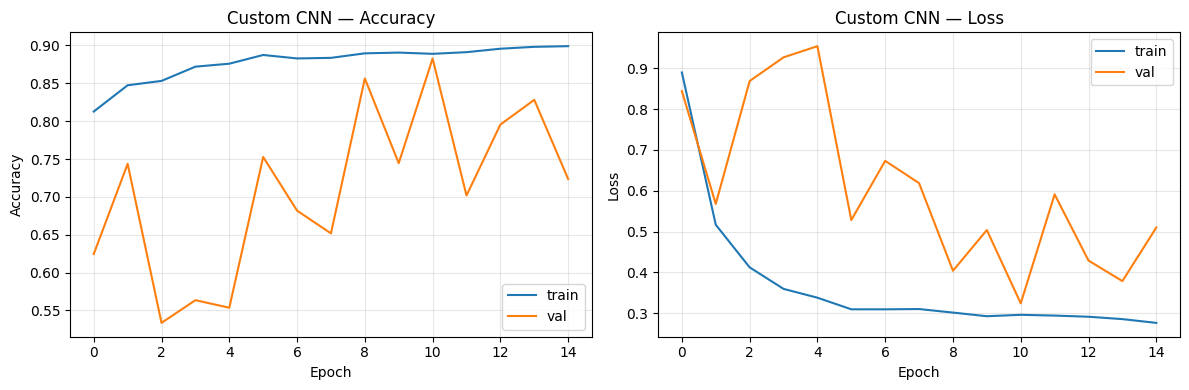

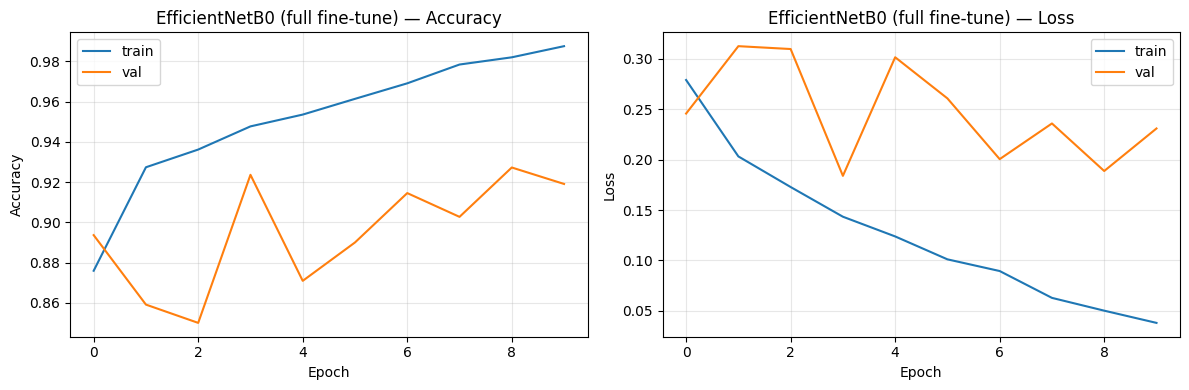

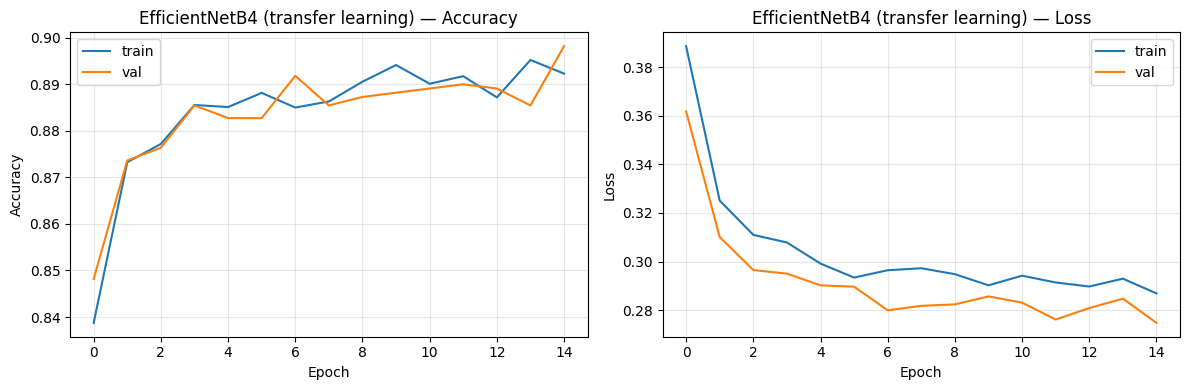

In [20]:
def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history['accuracy'], label='train')
    axes[0].plot(history['val_accuracy'], label='val')
    axes[0].set_title(f'{model_name} — Accuracy')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history['loss'], label='train')
    axes[1].plot(history['val_loss'], label='val')
    axes[1].set_title(f'{model_name} — Loss')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

for name, hist in histories.items():
    plot_history(hist, name)


## 13. Evaluate each model — Accuracy, Precision, Recall, F1, AUC
`malignant` (label = 1) is the **positive class**, as agreed — recall on malignant is the metric
that matters most clinically (a missed malignant case is far costlier than a false alarm).

In [37]:
def list_images_recursive(base_dir):
    image_paths = []
    for root, _, files in os.walk(base_dir):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(os.path.join(root, file))
    return image_paths


test_files_all = list_images_recursive(TEST_DIR)
test_labels_all = []
for p in test_files_all:
    parent_dir_name = os.path.basename(os.path.dirname(p))
    label = 1 if parent_dir_name == POSITIVE_CLASS else 0
    test_labels_all.append(label)

print(f"Test images : {len(test_files_all)} | class counts: {Counter(test_labels_all)}")

test_ds = make_dataset(test_files_all, test_labels_all, training=False)
y_true = np.array(test_labels_all)


def evaluate_model(model, ds, y_true, threshold=0.5):
    y_prob = model.predict(ds, verbose=0).ravel()
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, pos_label=1),
        "recall": recall_score(y_true, y_pred, pos_label=1),
        "f1": f1_score(y_true, y_pred, pos_label=1),
        "auc": roc_auc_score(y_true, y_prob),
        "y_prob": y_prob,
        "y_pred": y_pred,
    }

test_results = {}
for name, model in trained_models.items():
    print(f"Evaluating: {name}")
    test_results[name] = evaluate_model(model, test_ds, y_true)

results_df = pd.DataFrame({
    name: {k: v for k, v in res.items() if k not in ("y_prob", "y_pred")}
    for name, res in test_results.items()
}).T
results_df = results_df.round(4)
results_df

Test images : 1100 | class counts: Counter({1: 550, 0: 550})
Evaluating: Custom CNN
Evaluating: EfficientNetB0 (full fine-tune)
Evaluating: EfficientNetB4 (transfer learning)


,accuracy,precision,recall,f1,auc
Custom CNN,0.8145,0.8240,0.8000,0.8118,0.8966
EfficientNetB0 (full fine-tune),0.7745,0.9467,0.5818,0.7207,0.9356
EfficientNetB4 (transfer learning),0.7227,0.8490,0.5418,0.6615,0.8662


### Confusion matrices & classification reports (per model)


=== Custom CNN ===
              precision    recall  f1-score   support

      benign       0.81      0.83      0.82       550
   malignant       0.82      0.80      0.81       550

    accuracy                           0.81      1100
   macro avg       0.81      0.81      0.81      1100
weighted avg       0.81      0.81      0.81      1100



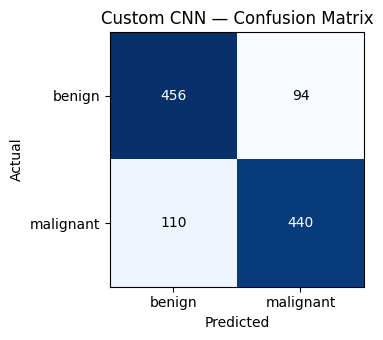


=== EfficientNetB0 (full fine-tune) ===
              precision    recall  f1-score   support

      benign       0.70      0.97      0.81       550
   malignant       0.95      0.58      0.72       550

    accuracy                           0.77      1100
   macro avg       0.82      0.77      0.77      1100
weighted avg       0.82      0.77      0.77      1100



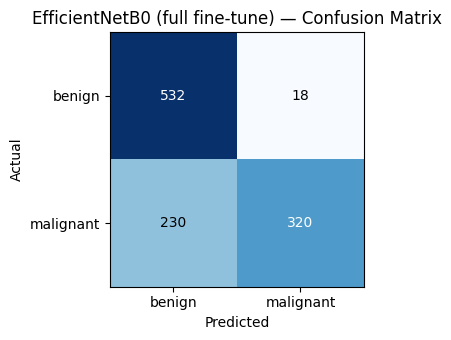


=== EfficientNetB4 (transfer learning) ===
              precision    recall  f1-score   support

      benign       0.66      0.90      0.77       550
   malignant       0.85      0.54      0.66       550

    accuracy                           0.72      1100
   macro avg       0.76      0.72      0.71      1100
weighted avg       0.76      0.72      0.71      1100



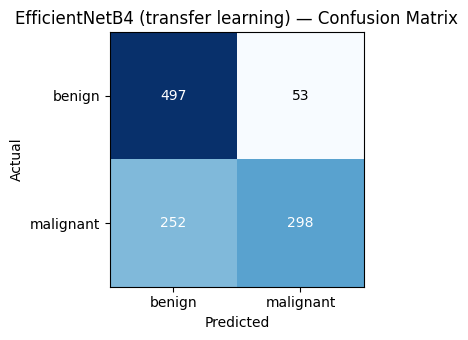

In [26]:
for name, res in test_results.items():
    print(f"\n=== {name} ===")
    print(classification_report(y_true, res["y_pred"], target_names=CLASS_NAMES))
    cm = confusion_matrix(y_true, res["y_pred"])
    fig, ax = plt.subplots(figsize=(4, 3.5))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1]); ax.set_xticklabels(CLASS_NAMES)
    ax.set_yticks([0, 1]); ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'{name} — Confusion Matrix')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max()/2 else 'black')
    plt.tight_layout()
    plt.show()


## 14. Model comparison — metrics bar chart

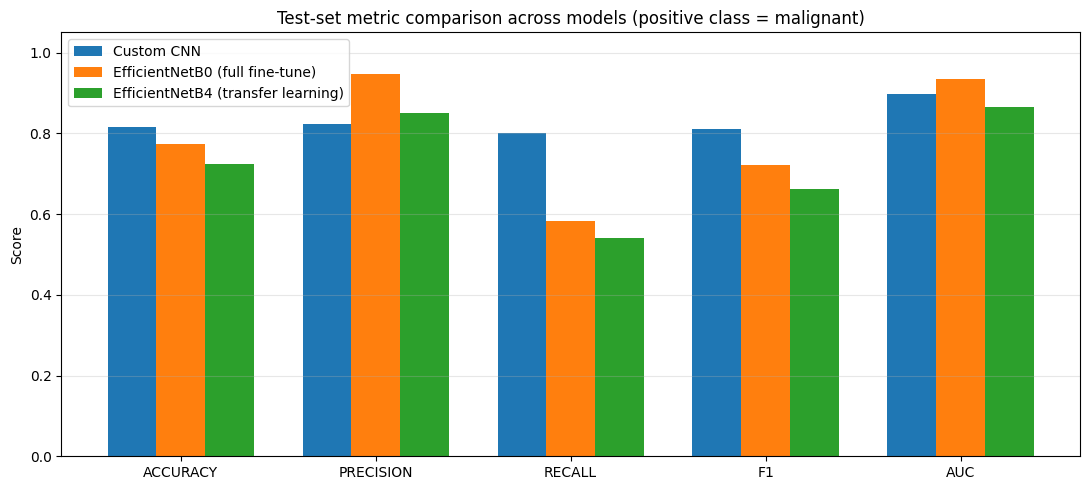

In [27]:
metrics_to_plot = ["accuracy", "precision", "recall", "f1", "auc"]
fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(metrics_to_plot))
width = 0.25
for i, (name, res) in enumerate(test_results.items()):
    values = [res[m] for m in metrics_to_plot]
    ax.bar(x + i*width, values, width, label=name)

ax.set_xticks(x + width)
ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Test-set metric comparison across models (positive class = malignant)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### ROC curves — all 3 models overlaid

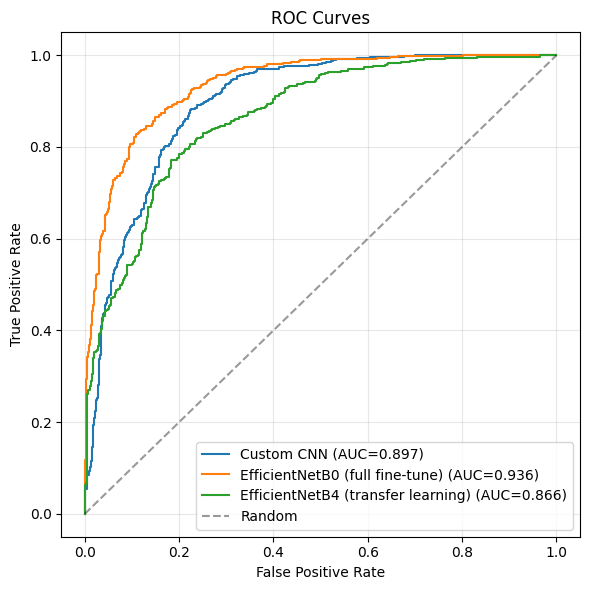

In [28]:
fig, ax = plt.subplots(figsize=(6, 6))
for name, res in test_results.items():
    fpr, tpr, _ = roc_curve(y_true, res["y_prob"])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})")
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label="Random")
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 15. Train vs Test accuracy — overfitting check

Final training accuracy (last epoch, i.e. right before early stopping / restore-best-weights kicked
in) vs. test accuracy, per model. A large gap flags overfitting — this is especially worth watching
for the full-fine-tune EfficientNetB0, which we already flagged as the highest overfitting risk.

In [29]:
train_acc_final = {name: hist['accuracy'][-1] for name, hist in histories.items()}
test_acc_final = {name: test_results[name]['accuracy'] for name in test_results}

comparison_df = pd.DataFrame({
    "Train Accuracy": train_acc_final,
    "Test Accuracy": test_acc_final,
})
comparison_df["Gap (Train - Test)"] = comparison_df["Train Accuracy"] - comparison_df["Test Accuracy"]
comparison_df = comparison_df.round(4)
comparison_df


,Train Accuracy,Test Accuracy,Gap (Train - Test)
Custom CNN,0.8990,0.8145,0.0845
EfficientNetB0 (full fine-tune),0.9876,0.7745,0.2131
EfficientNetB4 (transfer learning),0.8923,0.7227,0.1696


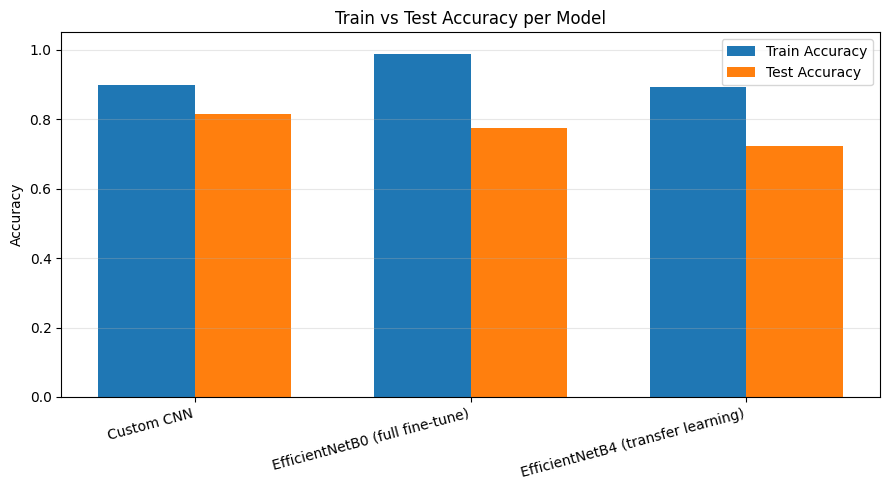

In [30]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(comparison_df))
width = 0.35
ax.bar(x - width/2, comparison_df["Train Accuracy"], width, label="Train Accuracy")
ax.bar(x + width/2, comparison_df["Test Accuracy"], width, label="Test Accuracy")
ax.set_xticks(x)
ax.set_xticklabels(comparison_df.index, rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Accuracy')
ax.set_title('Train vs Test Accuracy per Model')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 16. Bonus — misclassified sample inspection (best model)
A quick qualitative look at what the best-performing model gets wrong. Useful for your report's
error-analysis section even though it wasn't in the original ask.

Best model by F1: Custom CNN
Misclassified: 204 / 1100


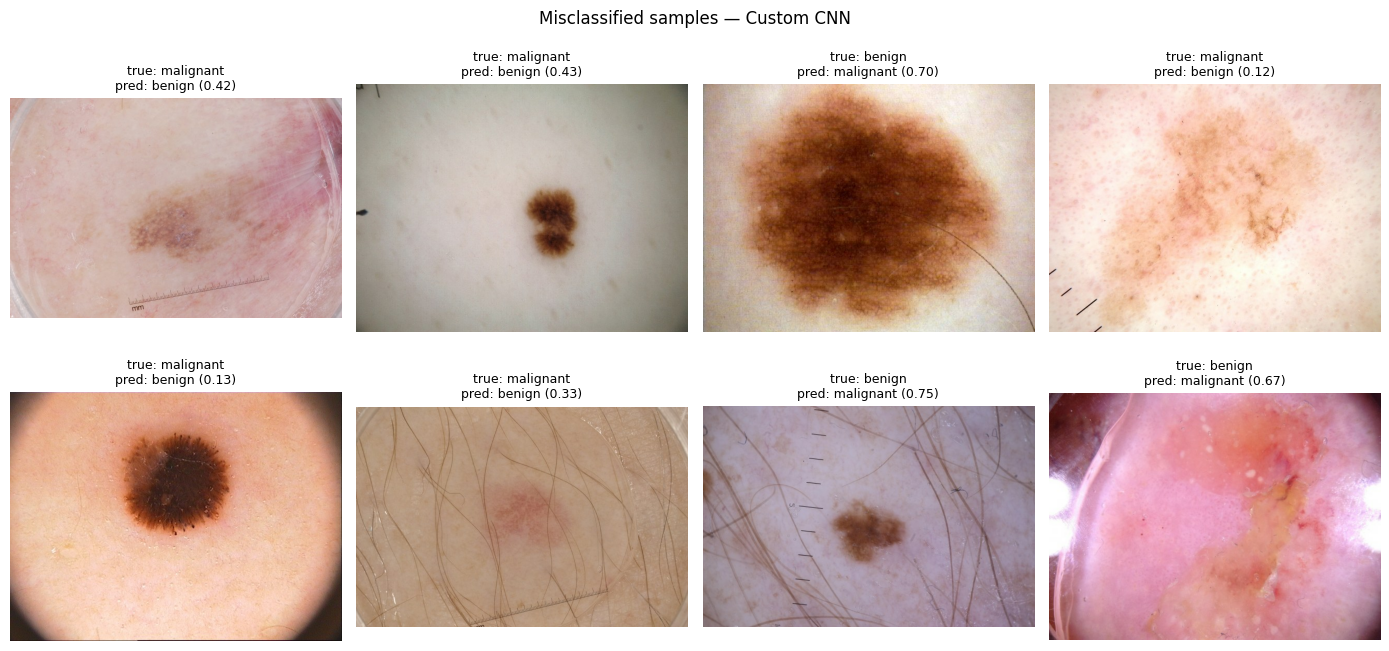

In [32]:
best_model_name = results_df["f1"].idxmax()
print("Best model by F1:", best_model_name)

res = test_results[best_model_name]
wrong_idx = np.where(res["y_pred"] != y_true)[0]
print(f"Misclassified: {len(wrong_idx)} / {len(y_true)}")

sample_idx = np.random.RandomState(SEED).choice(wrong_idx, size=min(8, len(wrong_idx)), replace=False)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, idx in zip(axes.ravel(), sample_idx):
    img = tf.io.read_file(test_files_all[idx]) # Changed from test_files_dedup to test_files_all
    img = tf.image.decode_jpeg(img, channels=3)
    ax.imshow(img.numpy())
    true_lbl = CLASS_NAMES[y_true[idx]]
    pred_lbl = CLASS_NAMES[res["y_pred"][idx]]
    conf = res["y_prob"][idx]
    ax.set_title(f"true: {true_lbl}\npred: {pred_lbl} ({conf:.2f})", fontsize=9)
    ax.axis('off')
plt.suptitle(f"Misclassified samples — {best_model_name}")
plt.tight_layout()
plt.show()

Correctly classified: 896 / 1100


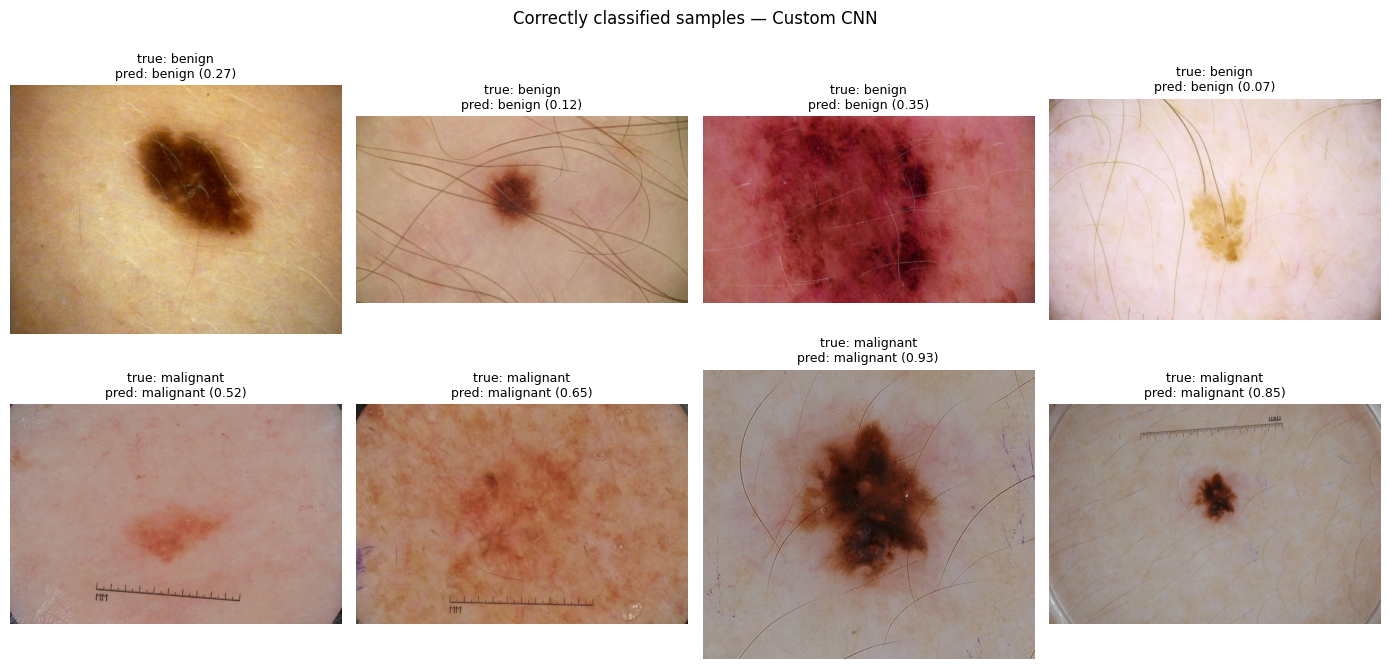

In [35]:
best_model_name = results_df["f1"].idxmax()
res = test_results[best_model_name]

# Find correctly classified samples
correct_idx = np.where(res["y_pred"] == y_true)[0]
print(f"Correctly classified: {len(correct_idx)} / {len(y_true)}")

sample_idx = np.random.RandomState(SEED).choice(correct_idx, size=min(8, len(correct_idx)), replace=False)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, idx in zip(axes.ravel(), sample_idx):
    img = tf.io.read_file(test_files_all[idx])
    img = tf.image.decode_jpeg(img, channels=3)
    ax.imshow(img.numpy())
    true_lbl = CLASS_NAMES[y_true[idx]]
    pred_lbl = CLASS_NAMES[res["y_pred"][idx]]
    conf = res["y_prob"][idx]
    ax.set_title(f"true: {true_lbl}\npred: {pred_lbl} ({conf:.2f})", fontsize=9)
    ax.axis('off')
plt.suptitle(f"Correctly classified samples — {best_model_name}")
plt.tight_layout()
plt.show()

## 17. Summary

In [34]:
print("="*70)
print("TRAINING & EVALUATION SUMMARY")
print("="*70)
print(f"Positive class: {POSITIVE_CLASS}")
print(f"Image size: {IMG_SIZE}, Batch size: {BATCH_SIZE}")
print(f"Class weights used: {class_weight_dict}")
print(f"Train images (post-dedup): {len(train_files)}")
print(f"Test images (no dedup):  {len(test_files_all)}  (0 duplicate(s) dropped)") # Changed variable to test_files_all and dropped count
print()
print("Test-set metrics:")
print(results_df.to_string())
print()
print("Train vs Test accuracy:")
print(comparison_df.to_string())
print()
print(f"Best model by F1: {best_model_name}")
print("="*70)

TRAINING & EVALUATION SUMMARY
Positive class: malignant
Image size: (224, 224), Batch size: 32
Class weights used: {0: np.float64(0.8846153846153846), 1: np.float64(1.15)}
Train images (post-dedup): 9200
Test images (no dedup):  1100  (0 duplicate(s) dropped)

Test-set metrics:
                                    accuracy  precision  recall      f1     auc
Custom CNN                            0.8145     0.8240  0.8000  0.8118  0.8966
EfficientNetB0 (full fine-tune)       0.7745     0.9467  0.5818  0.7207  0.9356
EfficientNetB4 (transfer learning)    0.7227     0.8490  0.5418  0.6615  0.8662

Train vs Test accuracy:
                                    Train Accuracy  Test Accuracy  Gap (Train - Test)
Custom CNN                                  0.8990         0.8145              0.0845
EfficientNetB0 (full fine-tune)             0.9876         0.7745              0.2131
EfficientNetB4 (transfer learning)          0.8923         0.7227              0.1696

Best model by F1: Custom CNN


## Test Set Results

The table below summarises the performance of each model on the test set, with 'malignant' as the positive class:

```
| Model                              | accuracy | precision | recall | f1     | auc    |
|:-----------------------------------|:---------|:----------|:-------|:-------|:-------|
| Custom CNN                         | 0.8145   | 0.8240    | 0.8000 | 0.8118 | 0.8966 |
| EfficientNetB0 (full fine-tune)    | 0.7745   | 0.9467    | 0.5818 | 0.7207 | 0.9356 |
| EfficientNetB4 (transfer learning) | 0.7227   | 0.8490    | 0.5418 | 0.6615 | 0.8662 |
```

Custom CNN achieves the highest F1 score (0.8118), accuracy (0.8145), and recall (0.8000). EfficientNetB0 (full fine-tune) has the highest precision (0.9467) and AUC (0.9356).

The ROC curves (shown earlier) demonstrate how each model performs across different thresholds. The bar chart of metrics visually reinforces the performance of each model on these key metrics.

Training accuracy for each model is notably higher than test accuracy, indicating some degree of overfitting. The gaps are as follows:

```
| Model                              | Train Accuracy | Test Accuracy | Gap (Train - Test) |
|:-----------------------------------|:---------------|:--------------|:-------------------|
| Custom CNN                         | 0.8990         | 0.8145        | 0.0845             |
| EfficientNetB0 (full fine-tune)    | 0.9876         | 0.7745        | 0.2131             |
| EfficientNetB4 (transfer learning) | 0.8923         | 0.7227        | 0.1696             |
```

Custom CNN shows the smallest train-test accuracy gap (0.0845), while EfficientNetB0 (full fine-tune) has the largest gap (0.2131).

## Model Selection: Why Custom CNN is Chosen

**Custom CNN** is selected as the best performing model. The selection is based on the following criteria:

*   **Highest F1 score of 0.8118:** This indicates a strong balance between precision and recall, crucial for a clinical setting where both false positives and false negatives have implications.
*   **Highest Accuracy of 0.8145:** It correctly classifies the highest percentage of unseen images.
*   **Highest Recall of 0.8000:** This is critical in a clinical setting as it minimizes false negatives (missed malignant cases).
*   **Smallest Train-Test Accuracy Gap of 0.0845:** This suggests better generalization to unseen data compared to the other models, despite some overfitting being present in all models.

While Custom CNN does not have the highest AUC or precision, its overall balance of metrics, particularly its F1 score and recall, combined with the lowest overfitting gap, makes it the most reliable choice among the three models evaluated for identifying malignant skin lesions. Further strategies to reduce overfitting, such as more aggressive regularization or a larger dataset, could be explored in future iterations for all models.